In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option('display.max_columns', None)

In [7]:
loksabha = pd.read_excel("Lokh Sabha seats.xlsx")
population = pd.read_excel("Year and Population.xlsx")
growth = pd.read_csv("Pop Growth.csv")

In [8]:
print(loksabha.shape)


(31, 3)


In [9]:
print(population.head())
print(growth.head())

   year   Population 
0   2026   1467231210
1   2025   1454606724
2   2024   1441719852
3   2023   1428627663
4   2022   1417173173
   Sl. No     States/UT  Population Growth Rate  Unnamed: 3  Unnamed: 4
0       1  NCT of Delhi                    18.3         NaN         NaN
1       2         Bihar                    14.4         NaN         NaN
2       3     Jharkhand                    12.5         NaN         NaN
3       4       Haryana                    12.0         NaN         NaN
4       5       Gujarat                    12.0         NaN         NaN


In [12]:
print(loksabha.describe())

       Current Lok Sabha Seats   Estimated Population Share (approx %) 
count                 31.000000                               31.000000
mean                  17.483871                                3.215806
std                   18.027518                                3.706770
min                    1.000000                                0.100000
25%                    3.000000                                0.400000
50%                   13.000000                                2.200000
75%                   25.500000                                5.000000
max                   80.000000                               17.000000


In [11]:
print(population.describe())

             year    Population 
count    77.000000  7.700000e+01
mean   1988.000000  8.693929e+08
std      22.371857  3.539927e+08
min    1950.000000  3.570211e+08
25%    1969.000000  5.453147e+08
50%    1988.000000  8.337297e+08
75%    2007.000000  1.189692e+09
max    2026.000000  1.467231e+09


In [13]:
print(growth.describe())

         Sl. No  Population Growth Rate  Unnamed: 3  Unnamed: 4
count  23.00000               23.000000         0.0         0.0
mean   12.00000                8.660870         NaN         NaN
std     6.78233                3.952875         NaN         NaN
min     1.00000                3.000000         NaN         NaN
25%     6.50000                5.600000         NaN         NaN
50%    12.00000                9.100000         NaN         NaN
75%    17.50000               11.550000         NaN         NaN
max    23.00000               18.300000         NaN         NaN


In [14]:
print(loksabha.isnull().sum())

State/ Union Terriotory                   0
Current Lok Sabha Seats                   0
Estimated Population Share (approx %)     0
dtype: int64


In [15]:
print(population.isnull().sum())

year           0
Population     0
dtype: int64


In [17]:
print(growth.isnull().sum())

Sl. No                     0
States/UT                  0
Population Growth Rate     0
Unnamed: 3                23
Unnamed: 4                23
dtype: int64


In [18]:
loksabha.rename(columns={
    "State/ Union Territory":"State",
    "Current Lok Sabha Seats":"Seats",
    "Estimated Population Share (approx %)":"PopulationShare"
}, inplace=True)

In [19]:
loksabha.columns

Index(['State/ Union Terriotory', 'Current Lok Sabha Seats ',
       'Estimated Population Share (approx %) '],
      dtype='object')

In [28]:
print(population.columns)

Index(['year ', 'Population '], dtype='object')


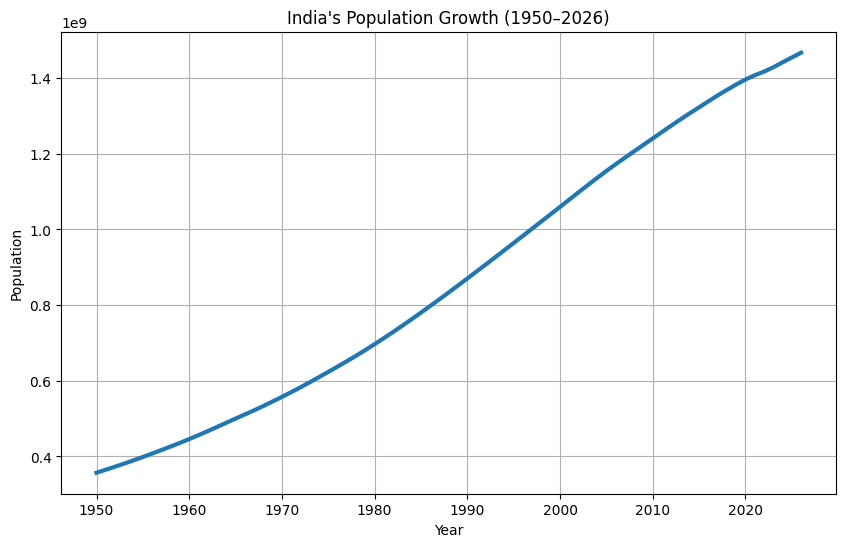

In [31]:
plt.figure(figsize=(10,6))

plt.plot(population["year "],
         population["Population "],
         linewidth=3)

plt.title("India's Population Growth (1950–2026)")

plt.xlabel("Year")
plt.ylabel("Population")

plt.grid(True)

plt.show()

India's population has increased steadily over the past seven decades. Such demographic changes explain why discussions around delimitation and representation have gained prominence.

In [32]:
growth = growth.sort_values(
    by="Population Growth Rate",
    ascending=False
)

In [35]:
print(growth.columns)

Index(['Sl. No', 'States/UT', 'Population Growth Rate', 'Unnamed: 3',
       'Unnamed: 4'],
      dtype='object')


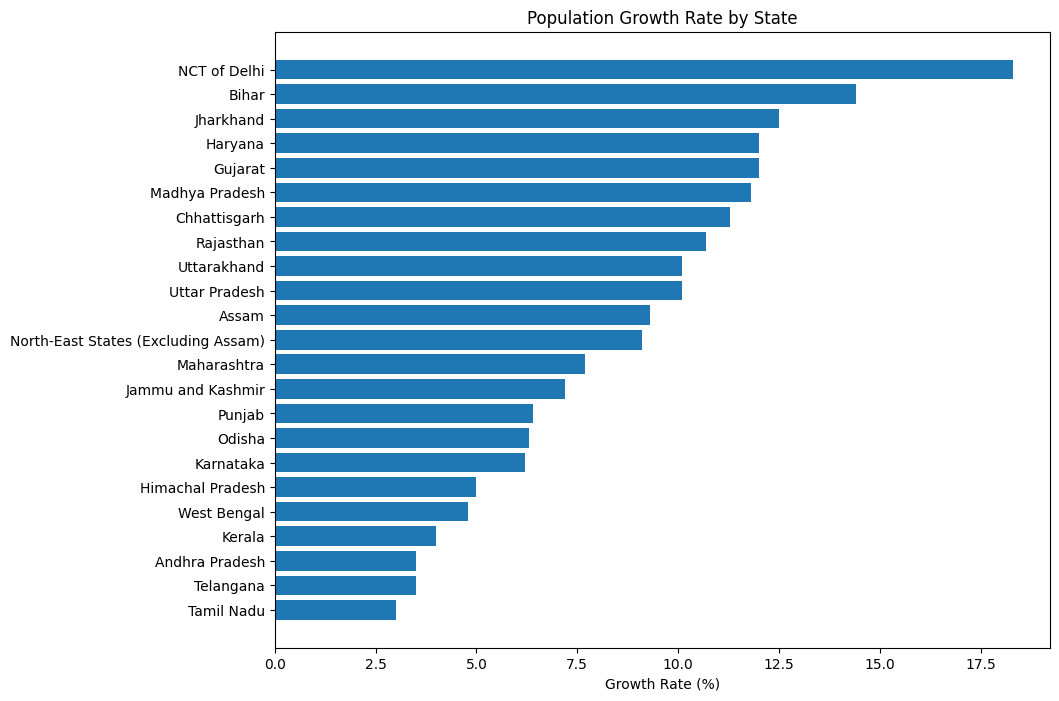

In [36]:
plt.figure(figsize=(10,8))

plt.barh(
    growth["States/UT"],
    growth["Population Growth Rate"])
plt.title("Population Growth Rate by State")
plt.xlabel("Growth Rate (%)")
plt.gca().invert_yaxis()
plt.show()

Population growth differs considerably across states, indicating that demographic change has not been uniform across the country.

In [38]:
print(loksabha.columns)

Index(['State/ Union Terriotory', 'Current Lok Sabha Seats ',
       'Estimated Population Share (approx %) '],
      dtype='object')


In [39]:
loksabha = loksabha.sort_values(
    by="Current Lok Sabha Seats ",
    ascending=False)

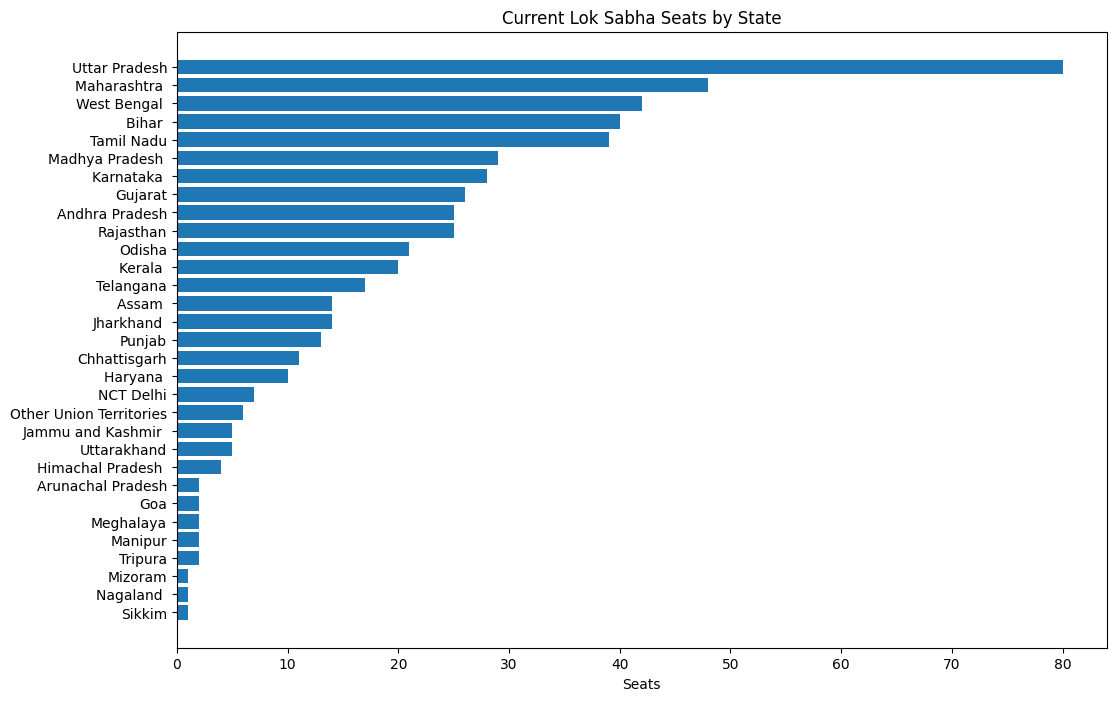

In [40]:
plt.figure(figsize=(12,8))

plt.barh(
    loksabha["State/ Union Terriotory"],
    loksabha["Current Lok Sabha Seats "])
plt.title("Current Lok Sabha Seats by State")
plt.xlabel("Seats")
plt.gca().invert_yaxis()
plt.show()

Observation
The distribution of Lok Sabha seats differs substantially across states. Larger states generally have more seats, reflecting their larger populations.

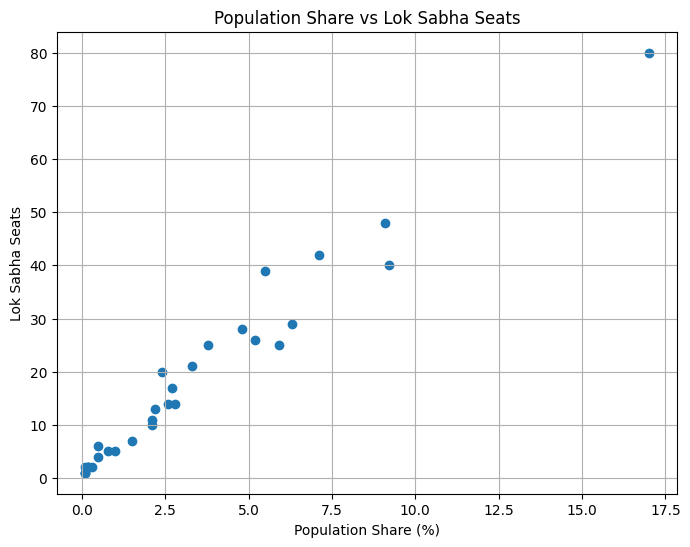

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    loksabha["Estimated Population Share (approx %) "],
    loksabha["Current Lok Sabha Seats "])
plt.xlabel("Population Share (%)")
plt.ylabel("Lok Sabha Seats")
plt.title("Population Share vs Lok Sabha Seats")
plt.grid(True)
plt.show()

The scatter plot shows a strong positive association between estimated population share and the number of Lok Sabha seats. This suggests that states with larger populations generally receive greater parliamentary representation.

In [42]:
correlation = loksabha["Estimated Population Share (approx %) "].corr(
    loksabha["Current Lok Sabha Seats "])
print("Correlation:", correlation)

Correlation: 0.9812626534020057


This represents a very strong correlation value, which indicates a strong positive relationship between population and seat matrix in the Parliament. This suggests that states with larger population shares generally have more parliamentary representation. However, correlation alone does not determine whether representation is perfectly proportional or whether it reflects current demographic realities.

In [43]:
loksabha["Representation Index"] = (
    loksabha["Current Lok Sabha Seats "] /
    loksabha["Estimated Population Share (approx %) "])

In [44]:
representation = loksabha.sort_values(
    by="Representation Index",
    ascending=False)
representation.head()

,State/ Union Terriotory,Current Lok Sabha Seats,Estimated Population Share (approx %),Representation Index
22,Arunachal Pradesh,2,0.1,20.0
30,Other Union Territories,6,0.5,12.0
23,Goa,2,0.2,10.0
29,Sikkim,1,0.1,10.0
28,Nagaland,1,0.1,10.0


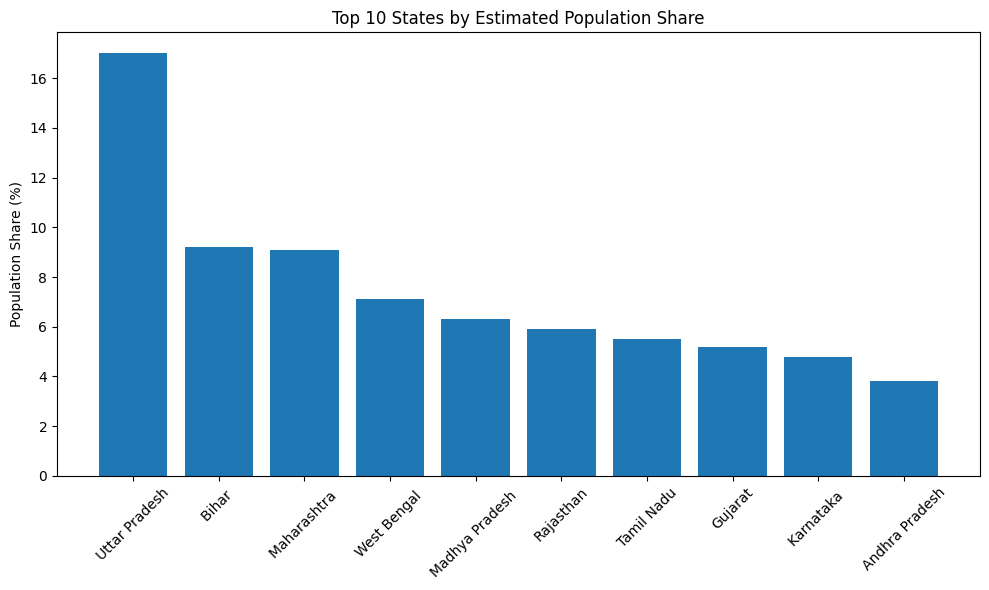

In [46]:
top10 = loksabha.sort_values(
    by="Estimated Population Share (approx %) ",
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
plt.bar(
    top10["State/ Union Terriotory"],
    top10["Estimated Population Share (approx %) "])
plt.xticks(rotation=45)
plt.ylabel("Population Share (%)")
plt.title("Top 10 States by Estimated Population Share")
plt.tight_layout()
plt.show()

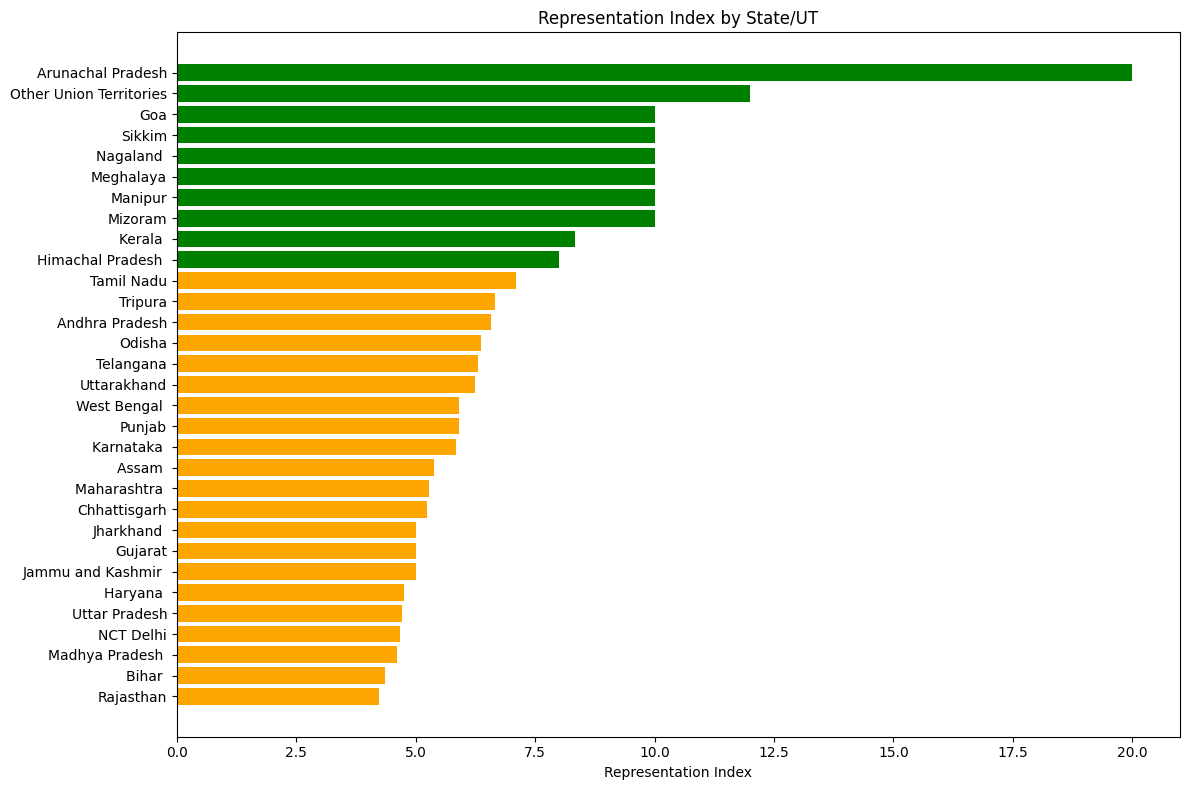

In [48]:
representation = loksabha.sort_values(
    by="Representation Index",
    ascending=False)
colors = ["green" if x >= representation["Representation Index"].mean()
          else "orange"
          for x in representation["Representation Index"]]
plt.figure(figsize=(12,8))
plt.barh(
    representation["State/ Union Terriotory"],
    representation["Representation Index"],
    color=colors
)
plt.title("Representation Index by State/UT")
plt.xlabel("Representation Index")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The Representation Index compares the number of Lok Sabha seats with each state's estimated population share. States with higher index values have more seats relative to their population share than states with lower index values. This index is a descriptive tool created for this analysis and does not, by itself, determine whether representation is equitable or whether delimitation is warranted.